In [13]:
import math 
import matplotlib.pyplot as plt
from collections import Counter

In [14]:
class KNN:
    def __init__(self, k=5): #testar com K = 1, 3, 5, 7, 9
        self.k = k

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def distancia(self, a, b):
        soma = 0
        for i in range(len(a)):
            soma += (a[i] - b[i]) ** 2
        return math.sqrt(soma)

    def predict_one(self, x):
        distancias = []

        for i in range(len(self.X_train)):
            d = self.distancia(x, self.X_train[i])
            distancias.append((d, self.y_train[i]))

        distancias.sort(key=lambda x: x[0])

        vizinhos = distancias[:self.k]
        classes = [classe for _, classe in vizinhos]

        return Counter(classes).most_common(1)[0][0]

    def predict(self, X):
        return [self.predict_one(x) for x in X]

In [15]:
def carregar_csv(caminho):
    X = []
    y = []

    with open(caminho, "r") as f:
        for linha in f:
            partes = linha.strip().split(",")

            atributos = list(map(int, partes[:9]))
            classe = partes[9]

            X.append(atributos)
            y.append(classe)

    return X, y

In [16]:

X_train, y_train = carregar_csv("/home/gustavo-munoz-dutra/Documentos/t1_IA/dataset_treino.csv")
X_test, y_test = carregar_csv("/home/gustavo-munoz-dutra/Documentos/t1_IA/dataset_testes.csv")

print("Treino:", len(X_train))
print("Teste:", len(X_test))

Treino: 886
Teste: 98


In [17]:
def acuracia(y_real, y_pred):
    acertos = sum(1 for i in range(len(y_real)) if y_real[i] == y_pred[i])
    return acertos / len(y_real)

In [18]:
def calcular_metricas(y_real, y_pred):
    classes = list(set(y_real))
    resultados = {}

    for classe in classes:
        tp = fp = fn = tn = 0

        for i in range(len(y_real)):
            if y_real[i] == classe and y_pred[i] == classe:
                tp += 1
            elif y_real[i] != classe and y_pred[i] == classe:
                fp += 1
            elif y_real[i] == classe and y_pred[i] != classe:
                fn += 1
            else:
                tn += 1

        precision = tp / (tp + fp) if (tp + fp) != 0 else 0
        recall = tp / (tp + fn) if (tp + fn) != 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

        resultados[classe] = {
            "precision": precision,
            "recall": recall,
            "f1": f1
        }

    return resultados


def media_metricas(metricas):
    precisions = []
    recalls = []
    f1s = []

    for valores in metricas.values():
        precisions.append(valores["precision"])
        recalls.append(valores["recall"])
        f1s.append(valores["f1"])

    return (
        sum(precisions)/len(precisions),
        sum(recalls)/len(recalls),
        sum(f1s)/len(f1s)
    )

In [19]:
ks = [1, 3, 5, 7, 9, 11]

acuracias = []
precisions_medias = []
recalls_medios = []
f1s_medios = []

for k in ks:
    knn = KNN(k=k)
    knn.fit(X_train, y_train)

    pred = knn.predict(X_test)

    acc = acuracia(y_test, pred)
    acuracias.append(acc)

    metricas = calcular_metricas(y_test, pred)
    p, r, f = media_metricas(metricas)

    precisions_medias.append(p)
    recalls_medios.append(r)
    f1s_medios.append(f)

    print(f"\nK={k}")
    print(f"Acurácia: {acc:.4f}")
    print(f"Precision média: {p:.4f}")
    print(f"Recall médio: {r:.4f}")
    print(f"F1 médio: {f:.4f}")


K=1
Acurácia: 0.6122
Precision média: 0.6189
Recall médio: 0.6200
F1 médio: 0.6170

K=3
Acurácia: 0.7551
Precision média: 0.7435
Recall médio: 0.7600
F1 médio: 0.7444

K=5
Acurácia: 0.7449
Precision média: 0.7282
Recall médio: 0.7500
F1 médio: 0.7209

K=7
Acurácia: 0.7449
Precision média: 0.7352
Recall médio: 0.7500
F1 médio: 0.7251

K=9
Acurácia: 0.7347
Precision média: 0.7018
Recall médio: 0.7400
F1 médio: 0.6980

K=11
Acurácia: 0.7551
Precision média: 0.7406
Recall médio: 0.7600
F1 médio: 0.7270


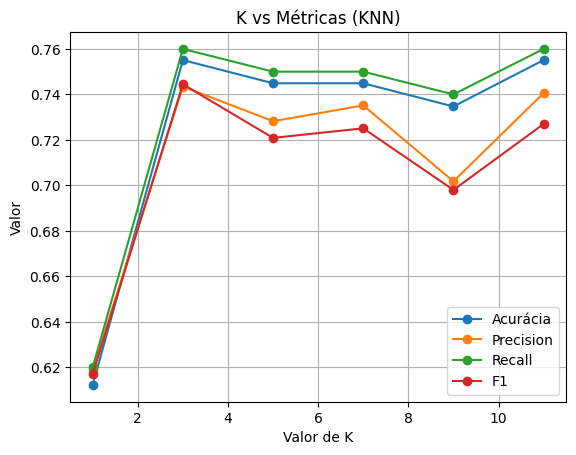

In [20]:
plt.figure()

plt.plot(ks, acuracias, marker='o', label="Acurácia")
plt.plot(ks, precisions_medias, marker='o', label="Precision")
plt.plot(ks, recalls_medios, marker='o', label="Recall")
plt.plot(ks, f1s_medios, marker='o', label="F1")

plt.title("K vs Métricas (KNN)")
plt.xlabel("Valor de K")
plt.ylabel("Valor")
plt.legend()
plt.grid()

plt.show()

In [21]:
melhor_k = ks[acuracias.index(max(acuracias))]
print("Melhor K:", melhor_k)

Melhor K: 3


In [22]:
def tabuleiro_para_vetor(tab):
    vetor = []

    for linha in tab:
        for c in linha:
            if c == 'X':
                vetor.append(1)
            elif c == 'O':
                vetor.append(-1)
            else:
                vetor.append(0)

    return vetor

In [23]:
knn = KNN(k=melhor_k)
knn.fit(X_train, y_train)

tabuleiro = [
    ['X', 'O', 'X'],
    ['O', 'X', ' '],
    [' ', 'O', ' ']
]

vetor = tabuleiro_para_vetor(tabuleiro)
estado = knn.predict_one(vetor)

print("Estado do jogo:", estado)

Estado do jogo: Tem jogo


In [24]:
import random

# ========= PADRONIZAÇÃO =========
def normalizar(classe):
    classe = classe.lower().replace(" ", "_")

    if "possibilidade" in classe or "possivel" in classe:
        return "possivel_fim"
    if "tem" in classe:
        return "tem_jogo"
    if "x" in classe and "vence" in classe:
        return "x_vence"
    if "o" in classe and "vence" in classe:
        return "o_vence"
    if "empate" in classe:
        return "empate"

    return classe


# ========= TABULEIRO -> VETOR =========
def tabuleiro_para_vetor(tab):
    vetor = []
    for linha in tab:
        for cel in linha:
            if cel == 'X':
                vetor.append(1)
            elif cel == 'O':
                vetor.append(-1)
            else:
                vetor.append(0)
    return vetor


# ========= MOSTRAR TABULEIRO =========
def mostrar_tabuleiro(tab):
    print()
    for i in range(3):
        print(" | ".join(tab[i]))
        if i < 2:
            print("-" * 9)
    print()


# ========= POSIÇÕES =========
def mostrar_posicoes():
    print("\nPosições disponíveis:")
    print("1 | 2 | 3")
    print("4 | 5 | 6")
    print("7 | 8 | 9\n")


# ========= ESTADO REAL =========
def estado_real(tab):
    linhas = tab
    colunas = [[tab[i][j] for i in range(3)] for j in range(3)]
    diagonais = [
        [tab[0][0], tab[1][1], tab[2][2]],
        [tab[0][2], tab[1][1], tab[2][0]]
    ]

    for grupo in linhas + colunas + diagonais:
        if grupo == ['X','X','X']:
            return "X_vence"
        if grupo == ['O','O','O']:
            return "O_vence"

    if all(tab[i][j] != ' ' for i in range(3) for j in range(3)):
        return "Empate"

    for grupo in linhas + colunas + diagonais:
        if grupo.count('X') == 2 and grupo.count(' ') == 1:
            return "Possivel_fim"
        if grupo.count('O') == 2 and grupo.count(' ') == 1:
            return "Possivel_fim"

    return "Tem_jogo"


# ========= JOGADA USUÁRIO (CORRIGIDA) =========
def jogada_usuario(tab):
    while True:
        mostrar_posicoes()
        pos = input("Escolha posição (1-9): ").strip()

        if not pos.isdigit():
            print("Digite um número de 1 a 9.")
            continue

        pos = int(pos)

        if pos < 1 or pos > 9:
            print("Digite um número de 1 a 9.")
            continue

        i = (pos - 1) // 3
        j = (pos - 1) % 3

        if tab[i][j] != ' ':
            print("Posição ocupada!")
            continue

        tab[i][j] = 'X'
        break


# ========= JOGADA MÁQUINA =========
def jogada_maquina(tab):
    vazios = [(i,j) for i in range(3) for j in range(3) if tab[i][j] == ' ']
    if vazios:
        i, j = random.choice(vazios)
        tab[i][j] = 'O'


# ========= LOOP =========
def jogar():
    tabuleiro = [[' ']*3 for _ in range(3)]

    acertos = 0
    erros = 0

    while True:
        mostrar_tabuleiro(tabuleiro)

        # ===== USUÁRIO =====
        jogada_usuario(tabuleiro)

        vetor = tabuleiro_para_vetor(tabuleiro)
        pred = knn.predict_one(vetor)
        real = estado_real(tabuleiro)

        print(f"IA: {pred} | Real: {real}")

        if normalizar(pred) == normalizar(real):
            acertos += 1
        else:
            erros += 1

        if real in ["X_vence", "O_vence", "Empate"]:
            if normalizar(pred) == normalizar(real):
                print("\n✅ Fim detectado corretamente!")
                break
            else:
                print("\n❌ IA errou o fim → continuando...")

        # ===== MÁQUINA =====
        jogada_maquina(tabuleiro)

        vetor = tabuleiro_para_vetor(tabuleiro)
        pred = knn.predict_one(vetor)
        real = estado_real(tabuleiro)

        print(f"IA: {pred} | Real: {real}")

        if normalizar(pred) == normalizar(real):
            acertos += 1
        else:
            erros += 1

        if real in ["X_vence", "O_vence", "Empate"]:
            if normalizar(pred) == normalizar(real):
                print("\n✅ Fim detectado corretamente!")
                break
            else:
                print("\n❌ IA errou o fim → continuando...")

    total = acertos + erros

    print("\n===== RESULTADO FINAL =====")
    print("Acertos:", acertos)
    print("Erros:", erros)
    if total > 0:
        print("Acurácia:", round(acertos / total, 4))


# ========= EXECUTAR =========
jogar()


  |   |  
---------
  |   |  
---------
  |   |  


Posições disponíveis:
1 | 2 | 3
4 | 5 | 6
7 | 8 | 9

IA: Tem jogo | Real: Tem_jogo
IA: Tem jogo | Real: Tem_jogo

  |   |  
---------
  | X |  
---------
  | O |  


Posições disponíveis:
1 | 2 | 3
4 | 5 | 6
7 | 8 | 9

IA: Tem jogo | Real: Tem_jogo
IA: Possibilidade_fim | Real: Possivel_fim

  | X |  
---------
  | X |  
---------
  | O | O


Posições disponíveis:
1 | 2 | 3
4 | 5 | 6
7 | 8 | 9

IA: Tem jogo | Real: Possivel_fim
IA: Tem jogo | Real: Possivel_fim

  | X |  
---------
  | X | O
---------
X | O | O


Posições disponíveis:
1 | 2 | 3
4 | 5 | 6
7 | 8 | 9

IA: Fim_X_Vence | Real: Possivel_fim
IA: Fim_O_Vence | Real: O_vence

✅ Fim detectado corretamente!

===== RESULTADO FINAL =====
Acertos: 5
Erros: 3
Acurácia: 0.625
